Dataset Shape: (30139, 105)

HIGH INCOME ANALYSIS
High Income Rate: 24.90%

GENDER VS INCOME
income            0          1
sex_Male                      
False     88.621713  11.378287
True      68.604537  31.395463

AGE ANALYSIS
income
0    36.611585
1    43.960165
Name: age, dtype: float64

HOURS PER WEEK ANALYSIS
income
0    39.352008
1    45.707034
Name: hours.per.week, dtype: float64

EDUCATION ANALYSIS
Education Features:
['education.num', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college']

TOP FEATURES CORRELATED WITH INCOME
income                               1.000000
marital.status_Married-civ-spouse    0.445329
education.num                        0.335413
HasCapitalGain                       0.266033
age

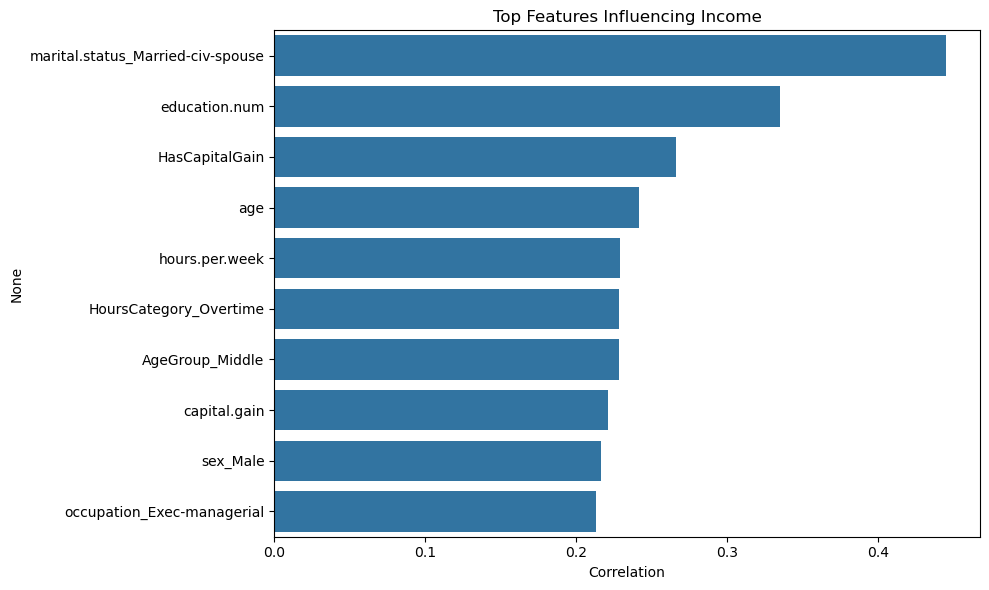


Business Insights Saved Successfully


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "../data/processed/engineered_adult.csv"
)

print("Dataset Shape:", df.shape)

# ==========================================
# HIGH INCOME RATE
# ==========================================

income_rate = df["income"].mean() * 100

print("\n================================")
print("HIGH INCOME ANALYSIS")
print("================================")
print(f"High Income Rate: {income_rate:.2f}%")

# ==========================================
# GENDER ANALYSIS
# ==========================================

print("\n================================")
print("GENDER VS INCOME")
print("================================")

if "sex_Male" in df.columns:

    gender_analysis = pd.crosstab(
        df["sex_Male"],
        df["income"],
        normalize="index"
    ) * 100

    print(gender_analysis)

# ==========================================
# AGE ANALYSIS
# ==========================================

print("\n================================")
print("AGE ANALYSIS")
print("================================")

print(df.groupby("income")["age"].mean())

# ==========================================
# HOURS PER WEEK ANALYSIS
# ==========================================

print("\n================================")
print("HOURS PER WEEK ANALYSIS")
print("================================")

print(
    df.groupby("income")["hours.per.week"]
    .mean()
)

# ==========================================
# EDUCATION ANALYSIS
# ==========================================

print("\n================================")
print("EDUCATION ANALYSIS")
print("================================")

education_cols = [
    col
    for col in df.columns
    if "education" in col.lower()
]

print("Education Features:")
print(education_cols)

# ==========================================
# TOP CORRELATIONS
# ==========================================

print("\n================================")
print("TOP FEATURES CORRELATED WITH INCOME")
print("================================")

corr = df.corr(numeric_only=True)

income_corr = (
    corr["income"]
    .sort_values(ascending=False)
)

print(income_corr.head(15))

# ==========================================
# VISUALIZATION
# ==========================================

top_features = (
    income_corr
    .drop("income")
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title(
    "Top Features Influencing Income"
)

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

# ==========================================
# SAVE REPORT
# ==========================================

income_corr.to_csv(
    "../reports/business_insights.csv"
)

print("\nBusiness Insights Saved Successfully")